# E-commerce Analysis

### Phase 1: importing libraries and the files

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 


##### - Reading the file and reviewing it

In [2]:
df = pd.read_csv("ecommerce_data.csv")
print(df)

     order_id        date     product     category  price  quantity  revenue  \
0           1  2025-03-04       Jeans     Clothing   1939         3     5817   
1           2  2025-01-23       Jeans     Clothing  44648         5   223240   
2           3  2025-02-25     T-Shirt     Clothing   2252         1     2252   
3           4  2025-02-20    Keyboard  Electronics   2039         5    10195   
4           5  2025-03-13       Watch  Accessories  29739         5   148695   
..        ...         ...         ...          ...    ...       ...      ...   
195       196  2025-04-04       Phone  Electronics   2486         5    12430   
196       197  2025-02-14  Headphones  Electronics  21711         4    86844   
197       198  2025-05-09       Mouse  Electronics  24276         5   121380   
198       199  2025-03-28  Headphones  Electronics  31878         3    95634   
199       200  2025-04-12       Jeans     Clothing   9524         2    19048   

      region  rating  
0      South    

In [3]:
# inspection of the data
print("Head:\n",df.head())
print("\nTail:\n",df.tail())
print("\nDescription:\n",df.describe())
df.shape
df.columns
df.info()
df.isnull().sum()
df.dtypes
df.nunique()

Head:
    order_id        date   product     category  price  quantity  revenue  \
0         1  2025-03-04     Jeans     Clothing   1939         3     5817   
1         2  2025-01-23     Jeans     Clothing  44648         5   223240   
2         3  2025-02-25   T-Shirt     Clothing   2252         1     2252   
3         4  2025-02-20  Keyboard  Electronics   2039         5    10195   
4         5  2025-03-13     Watch  Accessories  29739         5   148695   

    region  rating  
0    South       2  
1  Central       4  
2    South       5  
3  Central       4  
4    North       2  

Tail:
      order_id        date     product     category  price  quantity  revenue  \
195       196  2025-04-04       Phone  Electronics   2486         5    12430   
196       197  2025-02-14  Headphones  Electronics  21711         4    86844   
197       198  2025-05-09       Mouse  Electronics  24276         5   121380   
198       199  2025-03-28  Headphones  Electronics  31878         3    95634   
19

order_id    200
date        112
product      10
category      4
price       199
quantity      5
revenue     199
region        5
rating        5
dtype: int64

### Phase 1: Initial Data Exploration

### Dataset Overview
| Metric | Value |
|---------|---------|
| Total Rows | 200 |
| Total Columns | 9 |

### Numerical Columns
- `order_id`
- `price`
- `quantity`
- `revenue`
- `rating`

### Categorical Columns
- `date`
- `product`
- `category`
- `region`

### Missing Values Analysis
- No missing values found in the dataset.

### Rating Analysis
| Statistic | Value |
|-----------|-------|
| Average Rating | 2.94 |
| Minimum Rating | 1 |
| Maximum Rating | 5 |

### Revenue Analysis
| Statistic | Value |
|-----------|---------|
| Average Revenue | ₹75,450 |
| Maximum Revenue | ₹245,615 |

### Key Observations
- Dataset contains **200 records** and **9 features**.
- No missing values are present.
- Customer ratings range from **1 to 5**, with an average rating of **2.94**.
- Average revenue per order is approximately **₹75,450**.
- Highest recorded revenue is **₹245,615**.

### Phase-2: Data Cleaning and Validation

In [4]:
# missing values
df.isnull().sum()

print("\nDuplicates:", df.duplicated().sum())

# let's convert the date from object type to date format
df["date"] = pd.to_datetime(df["date"])

# checking the datatype again
print("Data type:\n",df.dtypes)


Duplicates: 0
Data type:
 order_id             int64
date        datetime64[us]
product                str
category               str
price                int64
quantity             int64
revenue              int64
region                 str
rating               int64
dtype: object


In [5]:
# validate the data (revenue)
revenue_check = (df["price"]*df["quantity"]==df["revenue"]).all()
print("Revenue Validation:", revenue_check)

Revenue Validation: True


In [6]:
# since the products may contain discounts and offer

df['discount'] = np.where(
    df["price"] > 25000,
    df['price'] * 0.10,
    df['price'] * 0.05
)

df['final_price'] = df['price'] - df['discount']
df.head()


,order_id,date,product,category,price,quantity,revenue,region,rating,discount,final_price
0,1,2025-03-04,Jeans,Clothing,1939,3,5817,South,2,96.95,1842.05
1,2,2025-01-23,Jeans,Clothing,44648,5,223240,Central,4,4464.80,40183.20
2,3,2025-02-25,T-Shirt,Clothing,2252,1,2252,South,5,112.60,2139.40
3,4,2025-02-20,Keyboard,Electronics,2039,5,10195,Central,4,101.95,1937.05
4,5,2025-03-13,Watch,Accessories,29739,5,148695,North,2,2973.90,26765.10


### Cleaning Summary
- Checked for missing values in the dataset.
- No missing values were found.
- Checked for duplicate records.
- No duplicate records were found.
- Converted the `date` column from string format to datetime format.

### Additional Edits
- Created a new `discount` column using NumPy.
- Products priced above ₹25,000 were given a 10% discount.
- Products priced at or below ₹25,000 were given a 5% discount.
- Created a `final_price` column after applying discounts.


### Phase-3 : Analytical Thinking and Approach

In [7]:
# Total Revenue
total_revenue = df['revenue'].sum()
print("Total Revenue:", total_revenue)

# Average Rating
avg_rating = df['rating'].mean()
print('Average Rating:', avg_rating)

# Revenue By Product
product_revenue = df.groupby("product")['revenue'].sum().sort_values(ascending=False)
print(product_revenue)

# Revenue by Category
categ_revenue = df.groupby("category")['revenue'].sum().sort_values(ascending=False)
print(categ_revenue)

# Revenue by Region
region_revenue = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
print(region_revenue)

# Quantity sold by Product
prod_quantity = df.groupby('product')['quantity'].sum().sort_values(ascending=False)
print(prod_quantity)

# Average Rating by Product
product_rating = df.groupby('product')['rating'].mean().sort_values(ascending=False)
print(product_rating)

Total Revenue: 15090073
Average Rating: 2.935
product
Watch         2278026
Jeans         2137299
Laptop        1902294
Keyboard      1828067
Mouse         1678865
Headphones    1595148
Phone         1197539
Backpack      1058564
Shoes          797132
T-Shirt        617139
Name: revenue, dtype: int64
category
Electronics    8201913
Accessories    3336590
Clothing       2754438
Footwear        797132
Name: revenue, dtype: int64
region
North      3604837
West       3205992
Central    3168332
East       2908936
South      2201976
Name: revenue, dtype: int64
product
Jeans         86
Watch         82
Mouse         81
Keyboard      69
Laptop        68
Headphones    66
Backpack      53
Phone         51
Shoes         38
T-Shirt       35
Name: quantity, dtype: int64
product
Keyboard      3.423077
Shoes         3.300000
Watch         3.000000
Backpack      3.000000
Mouse         2.916667
Jeans         2.857143
T-Shirt       2.818182
Headphones    2.772727
Phone         2.750000
Laptop        2.5

#### Insights gained from the above analysis


1. Total Revenue generated by the business is ₹15,090,073.

2. Watch is the highest revenue-generating product with revenue of ₹2,278,026.

3. Electronics is the best-performing category, contributing ₹8,201,913 in revenue.

4. North region generates the highest revenue (₹3,604,837), making it the strongest market.

5. Jeans is the most sold product with 86 units sold.

6. Keyboard is the highest-rated product with an average rating of 3.42.

7. Shoes has relatively high customer ratings but lower revenue, indicating potential growth opportunities through targeted marketing.

8. Laptop generates high revenue despite lower customer ratings, suggesting that product improvement initiatives may further increase sales performance.

### Phase 4: Data Visualization

The following visualizations were created to better understand product performance, category contribution, customer ratings, and regional sales distribution.

Visual insights help businesses identify revenue-driving products, profitable categories, and high-performing markets.

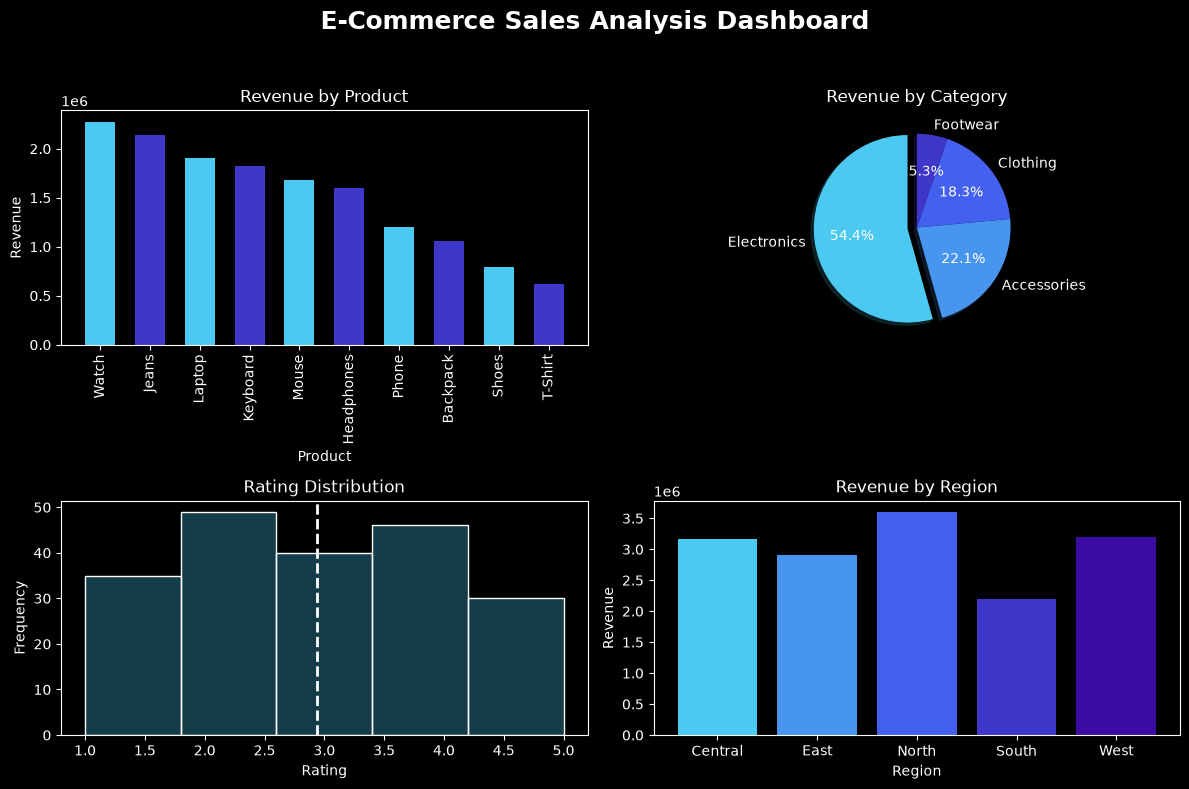

In [8]:
# Data for graphs
product_revenue = df.groupby("product")["revenue"].sum().sort_values(ascending=False)

category_revenue = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

region_revenue = df.groupby("region")["revenue"].sum()

# Create subplots
plt.style.use('dark_background')
colors = ['#4CC9F0',"#3F37C9"]

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(
    "E-Commerce Sales Analysis Dashboard",
    fontsize=18,
    fontweight="bold",
    color="white"
)


# Graph 1 - Product Revenue
ax[0,0].bar(product_revenue.index, product_revenue.values, color=colors, width = 0.60)
ax[0,0].set_title("Revenue by Product")
ax[0,0].set_xlabel("Product")
ax[0,0].set_ylabel("Revenue")
ax[0,0].tick_params(axis='x', rotation=90)

# Graph 2 - Category Revenue Pie Chart
explode = [0.1,0,0,0]
piecolors = [
    "#4CC9F0",
    "#4895EF",
    "#4361EE",
    "#3F37C9",
    "#3A0CA3"
]
ax[0,1].pie(category_revenue.values, labels=category_revenue.index, autopct="%1.1f%%", shadow= True, startangle = 90, explode = explode, colors = piecolors)
ax[0,1].set_title("Revenue by Category")

# Graph 3 - Rating Distribution
ax[1,0].hist(df["rating"], bins=5, edgecolor = 'white', color="#38A4C460",)
ax[1,0].axvline(avg_rating,linestyle='--', linewidth = 2, label = f'mean={avg_rating:.2f}')
ax[1,0].set_title("Rating Distribution")
ax[1,0].set_xlabel("Rating")
ax[1,0].set_ylabel("Frequency")

# Graph 4 - Region Revenue
regcolors = [
    "#4CC9F0",
    "#4895EF",
    "#4361EE",
    "#3F37C9",
    "#3A0CA3"
]
ax[1,1].bar(region_revenue.index, region_revenue.values, color = regcolors)
ax[1,1].set_title("Revenue by Region")
ax[1,1].set_xlabel("Region")
ax[1,1].set_ylabel("Revenue")

plt.tight_layout(rect=[0,0,1,0.95])

# Save image
plt.savefig("ecommerce_report.jpg")

plt.show()